# QA — Reconciliation Metabase vs Adjust (CDS Android)

Notebook orchestration: gọi `clients/` để lấy data, gọi `reconciliation/` để xử lý.
Toàn bộ logic thật nằm trong 2 package đó — sửa logic ở đó, không sửa ở đây.

Đối chiếu đủ 12 chỉ số: ROAS D0-D28, Revenue D0-D28, Cost, Installs — sai số tương đối
thống nhất `ratio = mb/adj`, ngưỡng `config.THRESHOLD_PCT`. Cohort chưa đủ maturity theo
`Cohort Age` bị loại khỏi so sánh tự động.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import config
import run_config as rc
from clients.adjust_client import AdjustClient
from clients.metabase_client import MetabaseClient
from reconciliation.normalize import normalize_metabase, normalize_adjust, filter_excluded_dates
from reconciliation.merge import merge_sources, report_join_gaps
from reconciliation.flags import build_detail
from reconciliation.summary import summarize, top_discrepancy
from reconciliation import eda

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. (Tuỳ chọn) Override config riêng cho lần chạy này

`config.EXCLUDED_DATES` và `config.DATA_ASOF_DATE` là kiến thức riêng theo từng lần chạy
(ngày nào bị lỗi, chốt dữ liệu vào lúc nào) — override trực tiếp ở đây thay vì sửa `config.py`
nếu chỉ dùng cho 1 lần đối chiếu cụ thể.

In [4]:
game = config.GAMES[rc.GAME_KEY]
adjust_app_token = config.get_adjust_app_token(rc.GAME_KEY)
adjust_extra_params = config.get_adjust_extra_params(rc.GAME_KEY, rc.NETWORK_KEY)   # <-- đổi từ game["adjust_extra_params"]
metabase_network_value = config.get_metabase_network_value(rc.NETWORK_KEY)          # <-- mới

config.EXCLUDED_DATES = rc.EXCLUDED_DATES
config.DATA_ASOF_DATE = rc.DATA_ASOF_DATE

metabase_date_range = f"{rc.DATE_PERIOD_START}~{rc.DATE_PERIOD_END}"   # không dùng nữa, xem cell Metabase bên dưới
adjust_date_period = f"{rc.DATE_PERIOD_START}:{rc.DATE_PERIOD_END}"

print(f"Đang chạy cho: {game['label']} — network: {rc.NETWORK_KEY}")
print(f"Khoảng ngày: {rc.DATE_PERIOD_START} -> {rc.DATE_PERIOD_END}")

Đang chạy cho: Game C (BCE) — Android — network: ['applovin', 'unity']
Khoảng ngày: 2026-08-01 -> 2026-09-17


## 1. Lấy dữ liệu Metabase

In [5]:
mb = MetabaseClient(base_url=config.METABASE_URL, api_key=config.METABASE_API_KEY)

parameters = mb.build_parameters(
    game["metabase_card_id"],
    date_from=rc.DATE_PERIOD_START,        # "2026-07-17" — plain date, không dùng dấu ~
    date_to=rc.DATE_PERIOD_END,
    network=metabase_network_value,        # "APPLOVIN" hoặc "UNITY" — 1 giá trị, không phải list
    game=game["metabase_game"],            # "Game A" — scalar, không phải ["Game A"]
    platform=game["metabase_platform"],    # "ANDROID" — scalar
)

df_mb = mb.query_card(game["metabase_card_id"], parameters)
print("Số dòng Metabase:", df_mb.shape[0])
df_mb.head()

Số dòng Metabase: 176


,Cohort Date,Game,Platform,Network,Campaign,Cost,Adjust Installs,CPI,ROAS D0,ROAS D3,...,ad_revenue_total_cal_d3,ad_revenue_total_cal_d7,ad_revenue_total_cal_d14,ad_revenue_total_cal_d28,revenue_total_cal_d0,revenue_total_cal_d3,revenue_total_cal_d7,revenue_total_cal_d14,revenue_total_cal_d28,Revenue Complete Through
0,2026-09-17T00:00:00Z,Game C,ANDROID,APPLOVIN,BCE Android - D28 BLDROAS - 250829,927.866559,657,1.412278,0.095493,NaN,...,NaN,NaN,NaN,NaN,0.000,0.0,0.0,0.0,0.0,2026-09-18T00:00:00Z
1,2026-09-17T00:00:00Z,Game C,ANDROID,APPLOVIN,BCE Android - D28 AdROAS - 260422,716.385356,1620,0.442213,0.119795,NaN,...,NaN,NaN,NaN,NaN,0.707,0.0,0.0,0.0,0.0,2026-09-18T00:00:00Z
2,2026-09-17T00:00:00Z,Game C,ANDROID,UNITY,BCE Android - D28 AdROAS - 260813,39.139637,126,0.310632,0.133370,NaN,...,NaN,NaN,NaN,NaN,0.000,0.0,0.0,0.0,0.0,2026-09-18T00:00:00Z
3,2026-09-16T00:00:00Z,Game C,ANDROID,APPLOVIN,BCE Android - D28 BLDROAS - 250829,1276.302219,957,1.333649,0.143087,NaN,...,NaN,NaN,NaN,NaN,29.636,0.0,0.0,0.0,0.0,2026-09-18T00:00:00Z
4,2026-09-16T00:00:00Z,Game C,ANDROID,APPLOVIN,BCE Android - D28 AdROAS - 260422,1011.905321,1927,0.525120,0.115637,NaN,...,NaN,NaN,NaN,NaN,0.000,0.0,0.0,0.0,0.0,2026-09-18T00:00:00Z


## 2. Lấy dữ liệu Adjust
Dùng `config.ADJUST_METRICS_CDS_ANDROID` — đã gồm đủ Installs, Cost, ROAS D0-D28, Revenue D0-D28.

In [6]:
adjust = AdjustClient(api_token=config.ADJUST_API_TOKEN)

df_adjust, adjust_totals = adjust.fetch_report(
    app_token=adjust_app_token,
    dimensions=["day", "network", "campaign_network"],
    metrics=config.get_adjust_metrics(rc.GAME_KEY),
    date_period=adjust_date_period,
    extra_params=adjust_extra_params,   # <-- đổi từ game["adjust_extra_params"]
)

print("Số dòng Adjust:", df_adjust.shape[0])
print("Totals:", adjust_totals)
df_adjust.head()

Số dòng Adjust: 176
Totals: {'installs': 172829.0, 'network_cost': 157543.9642, 'roas_cal_d0': 0.1045, 'roas_cal_d3': 0.2339, 'roas_cal_d7': 0.3159, 'roas_cal_d14': 0.3851, 'roas_cal_d28': 0.5079, 'ad_revenue_total_cal_d0': 16133.9671, 'ad_revenue_total_cal_d3': 34768.199, 'ad_revenue_total_cal_d7': 42492.525, 'ad_revenue_total_cal_d14': 41416.6817, 'ad_revenue_total_cal_d28': 17062.9985, 'revenue_total_cal_d0': 335.489, 'revenue_total_cal_d3': 2074.721, 'revenue_total_cal_d7': 3836.878, 'revenue_total_cal_d14': 5112.72, 'revenue_total_cal_d28': 4584.622}


,day,network,campaign_network,installs,network_cost,roas_cal_d0,roas_cal_d3,roas_cal_d7,roas_cal_d14,roas_cal_d28,ad_revenue_total_cal_d0,ad_revenue_total_cal_d3,ad_revenue_total_cal_d7,ad_revenue_total_cal_d14,ad_revenue_total_cal_d28,revenue_total_cal_d0,revenue_total_cal_d3,revenue_total_cal_d7,revenue_total_cal_d14,revenue_total_cal_d28
0,2026-09-01,Unity,BCE Android - D28 AdROAS - 260813,6599,1330.8843,0.0564,0.1371,0.1875,0.2488,0.0,75.0396,180.4382,247.5717,327.1679,0.0,0.0,1.99,1.99,3.99,0.0
1,2026-09-06,ALV,BCE Android - D28 AdROAS - 260422,4753,1758.9883,0.123,0.2308,0.3165,0.3806,0.0,216.2894,405.9219,556.6864,669.5231,0.0,0.0,0.0,0.0,0.0,0.0
2,2026-09-03,Unity,BCE Android - D28 BLDROAS - 260820,4469,2113.2731,0.0575,0.1274,0.1711,0.2101,0.0,121.4476,267.9015,359.6336,435.999,0.0,0.0,1.32,1.98,7.97,0.0
3,2026-09-02,Unity,BCE Android - D28 BLDROAS - 260820,4237,1624.6039,0.0528,0.1413,0.202,0.2783,0.0,85.7079,211.7205,291.9021,370.2173,0.0,0.0,17.853,36.293,81.894,0.0
4,2026-09-02,Unity,BCE Android - D28 AdROAS - 260813,4222,2274.2777,0.073,0.1637,0.2182,0.2667,0.0,166.0333,364.8967,488.8154,599.2217,0.0,0.0,7.36,7.36,7.36,0.0


## 3. Normalize + loại ngày lỗi + Merge

In [7]:
mb_norm = normalize_metabase(df_mb)
adj_norm = normalize_adjust(df_adjust)

mb_norm = filter_excluded_dates(mb_norm, config.EXCLUDED_DATES)
adj_norm = filter_excluded_dates(adj_norm, config.EXCLUDED_DATES)

merged = merge_sources(mb_norm, adj_norm)
join_stats = report_join_gaps(merged)


Khớp cả 2 nguồn: 175 dòng
Chỉ có ở Metabase: 1 dòng
Chỉ có ở Adjust: 1 dòng

⚠️ Chỉ có ở Metabase:
           date Campaign   Network
135  2026-09-07           APPLOVIN

⚠️ Chỉ có ở Adjust:
           date campaign_network network
138  2026-09-07          unknown     ALV


## 4. Tính bảng đối chiếu chi tiết (long-format)
Mỗi dòng = 1 cohort x 1 metric. Dùng `merged` đầy đủ (kể cả phần lệch join key) —
các dòng đó tự ra flag "N/A (thiếu dữ liệu)", không bị âm thầm bỏ qua.

In [8]:
metric_map = config.get_metric_map(rc.GAME_KEY)
detail = build_detail(merged, metric_map)
detail.head(10)

Cohort Age tính theo DATA_ASOF_DATE = 2026-09-17
EXCLUDE_IMMATURE_COHORTS = True
[CHỐT] Sai số tương đối ratio = mb/adj. Ngưỡng Discrepancy: |rel_diff_pct| > 5.0%

Bảng detail: 3009 dòng (= 177 cohort x 17 chỉ số)
Số dòng bị loại vì cohort chưa đủ maturity: 642


,cohort_date,network,campaign,metric,cohort_age_days,is_immature,mb_value,adjust_value,abs_diff,ratio,rel_diff_pct,flag
0,2026-08-01,APPLOVIN,BCE Android - D28 AdROAS - 250827,AD_REVENUE_D0,47,False,0.147951,0.1480,-0.000049,0.999669,-0.0331,OK
1,2026-08-01,APPLOVIN,BCE Android - D28 AdROAS - 260422,AD_REVENUE_D0,47,False,59.894265,62.8548,-2.960535,0.952899,-4.7101,OK
2,2026-08-01,APPLOVIN,BCE Android - D28 BLDROAS - 250829,AD_REVENUE_D0,47,False,236.277420,238.3720,-2.094580,0.991213,-0.8787,OK
3,2026-08-01,APPLOVIN,BCE Android - D28 AdROAS - 250827,AD_REVENUE_D14,47,False,1.003351,1.0034,-0.000049,0.999951,-0.0049,OK
4,2026-08-01,APPLOVIN,BCE Android - D28 AdROAS - 260422,AD_REVENUE_D14,47,False,213.626307,224.6559,-11.029593,0.950905,-4.9095,OK
5,2026-08-01,APPLOVIN,BCE Android - D28 BLDROAS - 250829,AD_REVENUE_D14,47,False,633.545940,638.2724,-4.726460,0.992595,-0.7405,OK
6,2026-08-01,APPLOVIN,BCE Android - D28 AdROAS - 250827,AD_REVENUE_D28,47,False,1.003351,1.0034,-0.000049,0.999951,-0.0049,OK
7,2026-08-01,APPLOVIN,BCE Android - D28 AdROAS - 260422,AD_REVENUE_D28,47,False,270.548777,281.8820,-11.333223,0.959794,-4.0206,OK
8,2026-08-01,APPLOVIN,BCE Android - D28 BLDROAS - 250829,AD_REVENUE_D28,47,False,735.362295,740.8835,-5.521205,0.992548,-0.7452,OK
9,2026-08-01,APPLOVIN,BCE Android - D28 AdROAS - 250827,AD_REVENUE_D3,47,False,0.950965,0.9510,-0.000035,0.999963,-0.0037,OK


## 5. Tổng hợp % Discrepancy — theo Campaign x Metric, và toàn hệ thống

In [9]:
summary_result = summarize(detail)
summary_by_campaign = summary_result["by_campaign"]
summary_overall = summary_result["overall"]


=== Tổng hợp theo từng Campaign ===
                          campaign          metric  n_valid  mean_abs_diff  mean_ratio  mean_abs_rel_diff_pct  median_abs_rel_diff_pct  p90_abs_rel_diff_pct  pct_discrepancy
 BCE Android - D28 AdROAS - 250827         ROAS_D0        3         0.0001      0.9995                 0.1511                   0.1469                0.2678           0.0000
 BCE Android - D28 AdROAS - 250827         ROAS_D3        3         0.0001      0.9990                 0.1076                   0.0169                0.2418           0.0000
 BCE Android - D28 AdROAS - 250827         ROAS_D7        3         0.0001      0.9990                 0.1090                   0.0166                0.2417           0.0000
 BCE Android - D28 AdROAS - 250827        ROAS_D14        3         0.0001      0.9990                 0.1091                   0.0166                0.2417           0.0000
 BCE Android - D28 AdROAS - 250827        ROAS_D28        3         0.0001      0.9991        

In [10]:
print([c for c in merged.columns if "ad_revenue" in c or "revenue_total" in c])

['ad_revenue_total_cal_d0_mb', 'ad_revenue_total_cal_d3_mb', 'ad_revenue_total_cal_d7_mb', 'ad_revenue_total_cal_d14_mb', 'ad_revenue_total_cal_d28_mb', 'revenue_total_cal_d0_mb', 'revenue_total_cal_d3_mb', 'revenue_total_cal_d7_mb', 'revenue_total_cal_d14_mb', 'revenue_total_cal_d28_mb', 'ad_revenue_total_cal_d0_adj', 'ad_revenue_total_cal_d3_adj', 'ad_revenue_total_cal_d7_adj', 'ad_revenue_total_cal_d14_adj', 'ad_revenue_total_cal_d28_adj', 'revenue_total_cal_d0_adj', 'revenue_total_cal_d3_adj', 'revenue_total_cal_d7_adj', 'revenue_total_cal_d14_adj', 'revenue_total_cal_d28_adj']


## 6. Top các dòng lệch nhiều nhất — ưu tiên kiểm tra trước

In [11]:
top = top_discrepancy(detail, top_n=20, per_campaign=5)

print("=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===")
display(top["top_overall"])

print("\n=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===")
display(top["top_per_campaign"])


=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
1258,2026-08-25,UNITY,BCE Android - D28 BLDROAS - 260820,ROAS_D14,0.043129,0.0072,0.035929,499.0106
1198,2026-08-25,UNITY,BCE Android - D28 BLDROAS - 260820,AD_REVENUE_D14,3.918610,0.6558,3.262810,497.5313
591,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D3,0.000445,0.0006,-0.000155,-25.7702
588,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D28,0.000445,0.0006,-0.000155,-25.7702
582,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D0,0.000445,0.0006,-0.000155,-25.7702
594,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D7,0.000445,0.0006,-0.000155,-25.7702
585,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D14,0.000445,0.0006,-0.000155,-25.7702
549,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,AD_REVENUE_D14,0.000160,0.0002,-0.000040,-20.0000
546,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,AD_REVENUE_D0,0.000160,0.0002,-0.000040,-20.0000
552,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,AD_REVENUE_D28,0.000160,0.0002,-0.000040,-20.0000



=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
427,2026-08-12,APPLOVIN,BCE Android - D28 AdROAS - 260422,AD_REVENUE_D14,120.776484,143.5422,-22.765716,-15.8599
451,2026-08-12,APPLOVIN,BCE Android - D28 AdROAS - 260422,ROAS_D14,0.328583,0.3905,-0.061917,-15.8558
453,2026-08-12,APPLOVIN,BCE Android - D28 AdROAS - 260422,ROAS_D28,0.391882,0.4564,-0.064518,-14.1363
429,2026-08-12,APPLOVIN,BCE Android - D28 AdROAS - 260422,AD_REVENUE_D28,144.042968,167.7491,-23.706132,-14.1319
433,2026-08-12,APPLOVIN,BCE Android - D28 AdROAS - 260422,AD_REVENUE_D7,98.904708,114.3572,-15.452492,-13.5125
591,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D3,0.000445,0.0006,-0.000155,-25.7702
588,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D28,0.000445,0.0006,-0.000155,-25.7702
582,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D0,0.000445,0.0006,-0.000155,-25.7702
594,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D7,0.000445,0.0006,-0.000155,-25.7702
585,2026-08-15,UNITY,BCE Android - D28 AdROAS - 260813,ROAS_D14,0.000445,0.0006,-0.000155,-25.7702


## 7. (Tuỳ chọn) Xuất kết quả
Thêm cell ghi `detail`/`summary_by_campaign`/`summary_overall` ra BigQuery / Google Sheets /
`.docx` report tại đây, khi bạn đã sẵn sàng nối vào pipeline output hiện có.

```python
# detail.to_csv("../outputs/reconciliation_detail.csv", index=False, encoding="utf-8-sig")
# summary_by_campaign.to_csv("../outputs/reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
# summary_overall.to_csv("../outputs/reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")
```

In [12]:
from pathlib import Path

output_dir = Path("../outputs") / rc.GAME_KEY
output_dir.mkdir(parents=True, exist_ok=True)

detail.to_csv(output_dir / "reconciliation_detail.csv", index=False, encoding="utf-8-sig")
summary_by_campaign.to_csv(output_dir / "reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
summary_overall.to_csv(output_dir / "reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")

df_mb.to_csv(output_dir / "mb.csv", index=False, encoding="utf-8-sig")
df_adjust.to_csv(output_dir / "adj.csv", index=False, encoding="utf-8-sig")

print(f"Đã xuất kết quả vào: {output_dir.resolve()}")

Đã xuất kết quả vào: D:\Document-D\2025.2\LabDATA\Game\QA\qa-pipeline\outputs\game_c_android


## 8. EDA — Phân tích trực quan

### 8.1. So sánh Tổng — Metabase vs Adjust
Tổng Cost/Installs/Revenue D0-D28 cộng dồn trên toàn bộ khoảng ngày đã chọn. Không gồm ROAS
(là tỷ lệ, cộng dồn không có ý nghĩa) — xem xu hướng ROAS ở mục 8.5.

=== So sánh TỔNG (cộng dồn toàn bộ khoảng ngày) ===
           metric      mb_total  adjust_total   n  rel_diff_pct
    AD_REVENUE_D0  15674.557148    16133.9103 175     -2.847128
    AD_REVENUE_D3  32075.633581    33059.4878 166     -2.976012
    AD_REVENUE_D7  38185.914713    39384.1527 152     -3.042437
   AD_REVENUE_D14  31439.321995    32370.2318 120     -2.875821
   AD_REVENUE_D28  14037.563149    14433.8343  52     -2.745432
   IAP_REVENUE_D0    335.489000      335.4890  45      0.000000
   IAP_REVENUE_D3   2018.577000     2018.5770  75      0.000000
   IAP_REVENUE_D7   3449.864000     3449.8640  74      0.000000
  IAP_REVENUE_D14   4623.188000     4623.1880  64      0.000000
  IAP_REVENUE_D28   3878.831000     3878.8310  30      0.000000
             COST 157543.966395   157543.9644 175      0.000001
         INSTALLS 172143.000000   172828.0000 175     -0.396348
 TOTAL_REVENUE_D0   8020.423639     8257.3167  45     -2.868887
 TOTAL_REVENUE_D3  26054.265002    26838.5504  75   

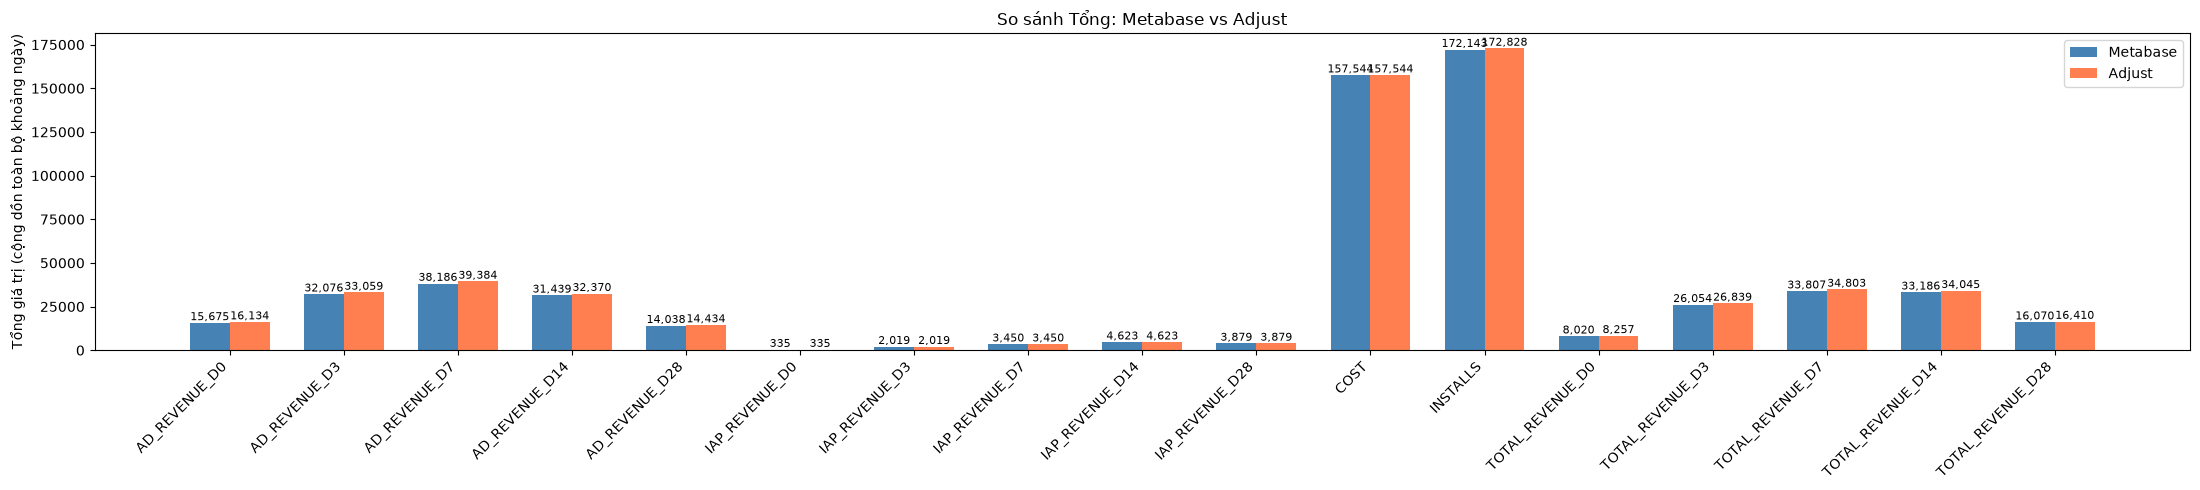

Đã lưu: D:\Document-D\2025.2\LabDATA\Game\QA\qa-pipeline\outputs\game_c_android\reconciliation_totals_comparison.csv


In [13]:
from pathlib import Path

output_dir = Path("../outputs") / rc.GAME_KEY
output_dir.mkdir(parents=True, exist_ok=True)

totals = eda.compare_totals(detail)
eda.plot_totals_comparison(totals)


print(f"Đã lưu: {(output_dir / 'reconciliation_totals_comparison.csv').resolve()}")

In [14]:
import reconciliation.eda as eda
print(eda.SUMMABLE_METRICS)

['COST', 'INSTALLS', 'AD_REVENUE_D0', 'AD_REVENUE_D3', 'AD_REVENUE_D7', 'AD_REVENUE_D14', 'AD_REVENUE_D28', 'IAP_REVENUE_D0', 'IAP_REVENUE_D3', 'IAP_REVENUE_D7', 'IAP_REVENUE_D14', 'IAP_REVENUE_D28']


In [15]:
print(sorted(detail["metric"].unique()))

['AD_REVENUE_D0', 'AD_REVENUE_D14', 'AD_REVENUE_D28', 'AD_REVENUE_D3', 'AD_REVENUE_D7', 'COST', 'IAP_REVENUE_D0', 'IAP_REVENUE_D14', 'IAP_REVENUE_D28', 'IAP_REVENUE_D3', 'IAP_REVENUE_D7', 'INSTALLS', 'ROAS_D0', 'ROAS_D14', 'ROAS_D28', 'ROAS_D3', 'ROAS_D7']


### 8.2. Tổng quan Campaign
Số lượng Campaign đang đối chiếu, và số ngày (cohort) mỗi Campaign có dữ liệu — giúp phát hiện
nhanh Campaign nào có mẫu quá nhỏ, cần cẩn trọng khi đọc % Discrepancy.

Số lượng Campaign đang đối chiếu: 8
                                    n_days  first_date   last_date
campaign                                                          
BCE Android - D28 AdROAS - 260422       48  2026-08-01  2026-09-17
BCE Android - D28 BLDROAS - 250829      48  2026-08-01  2026-09-17
BCE Android - D28 AdROAS - 260813       35  2026-08-14  2026-09-17
BCE Android - D28 BLDROAS - 260820      23  2026-08-20  2026-09-12
BCE Android - D7 AdROAS - 260817        18  2026-08-19  2026-09-08
BCE Android - D28 AdROAS - 250827        3  2026-08-01  2026-08-05
                                         1  2026-09-07  2026-09-07
unknown                                  1  2026-09-07  2026-09-07


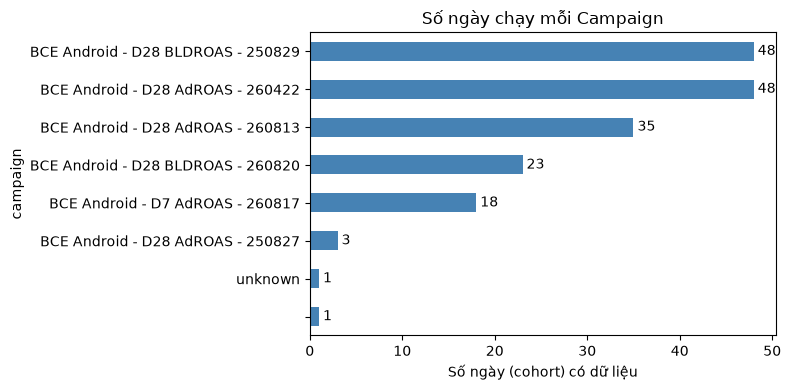

In [16]:
campaign_overview_df = eda.campaign_overview(detail)
eda.plot_campaign_overview(campaign_overview_df)

### 8.3. Heatmap % Discrepancy theo Campaign x Metric
Màu càng đỏ đậm, % Discrepancy càng cao — nhìn nhanh Campaign nào và Metric nào đang có vấn đề.

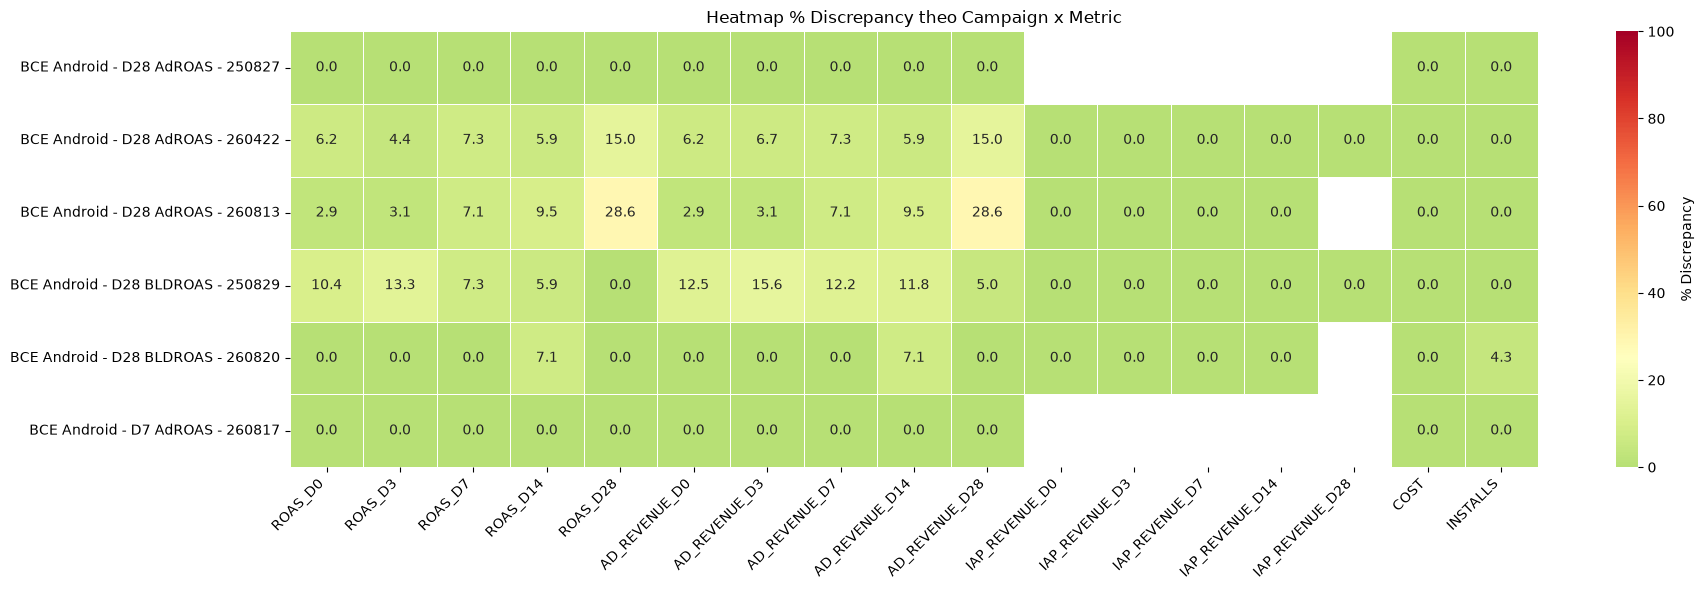

In [17]:
discrepancy_pivot = eda.plot_discrepancy_heatmap(summary_by_campaign)

### 8.4. Phân tích theo Metric — toàn hệ thống (gộp mọi Campaign)

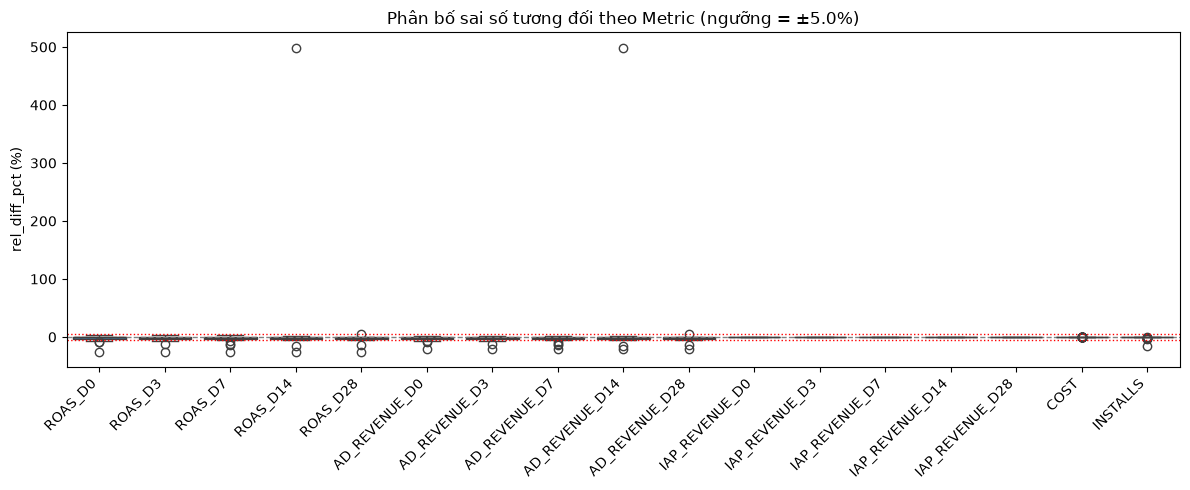

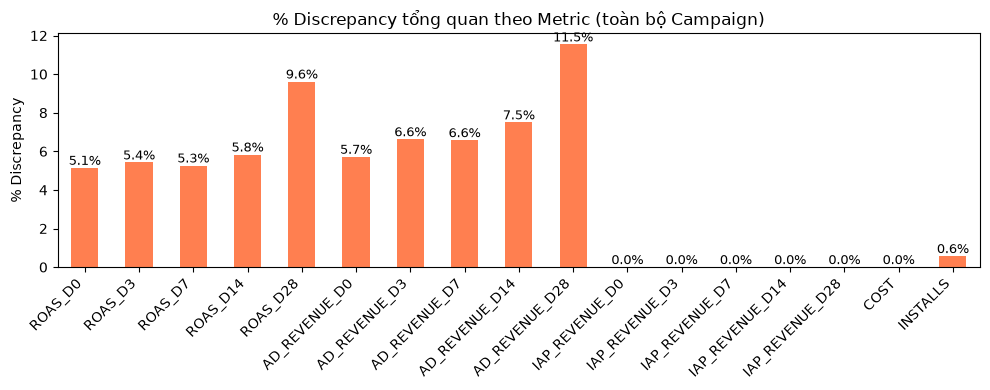

In [18]:
eda.plot_rel_diff_boxplot(detail)
eda.plot_overall_discrepancy_bar(summary_overall)

### 8.5. Xu hướng theo thời gian
- **Total**: trung bình `ratio = mb/adj` mỗi ngày, gộp tất cả campaign, cho vài metric đại diện.
- **Theo Campaign**: 1 đường/campaign, cho ĐÚNG 1 metric (đổi `metric=...` để xem chỉ số khác).

Đường `ratio = 1` (nét đứt) là khớp hoàn toàn.

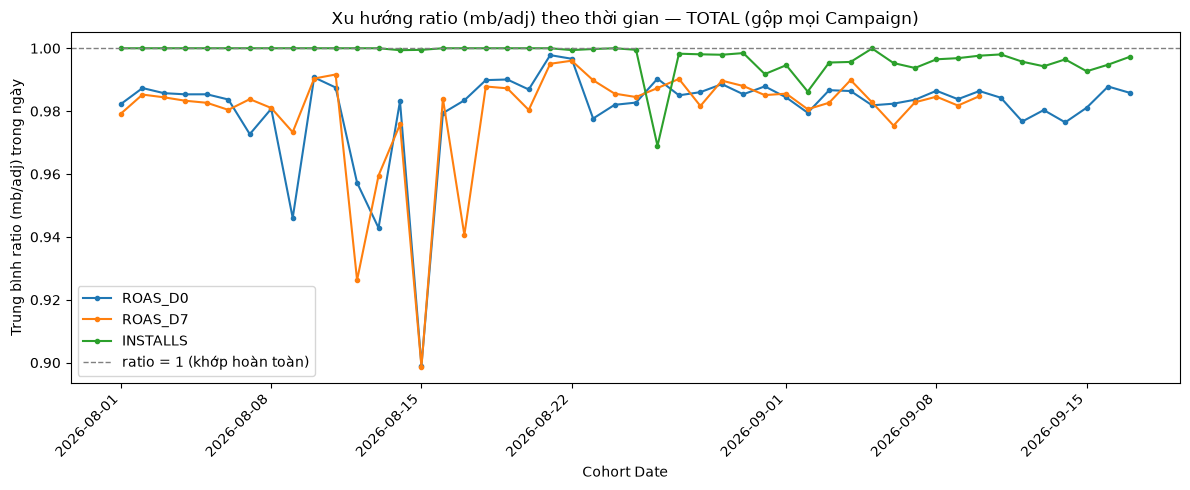

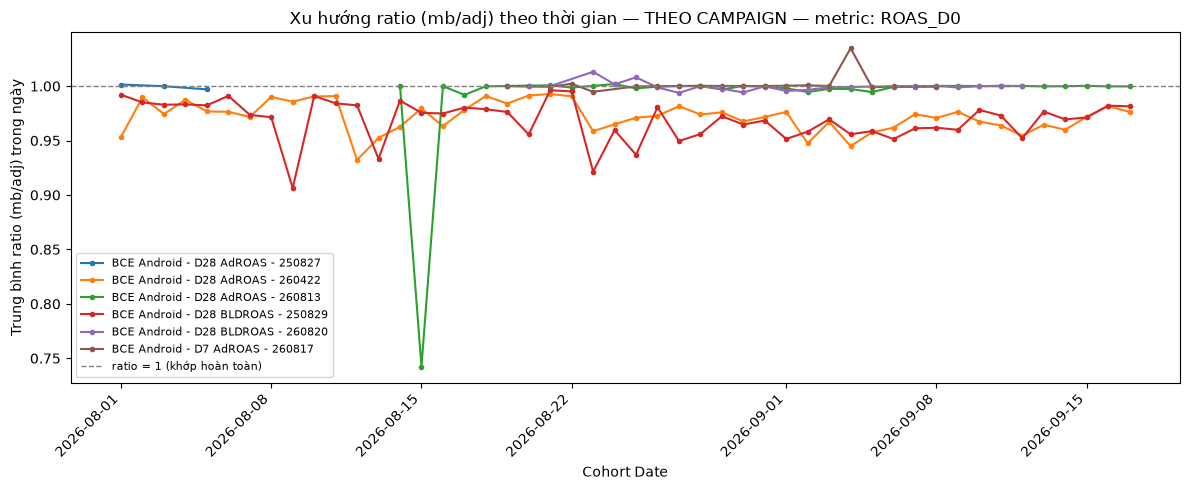

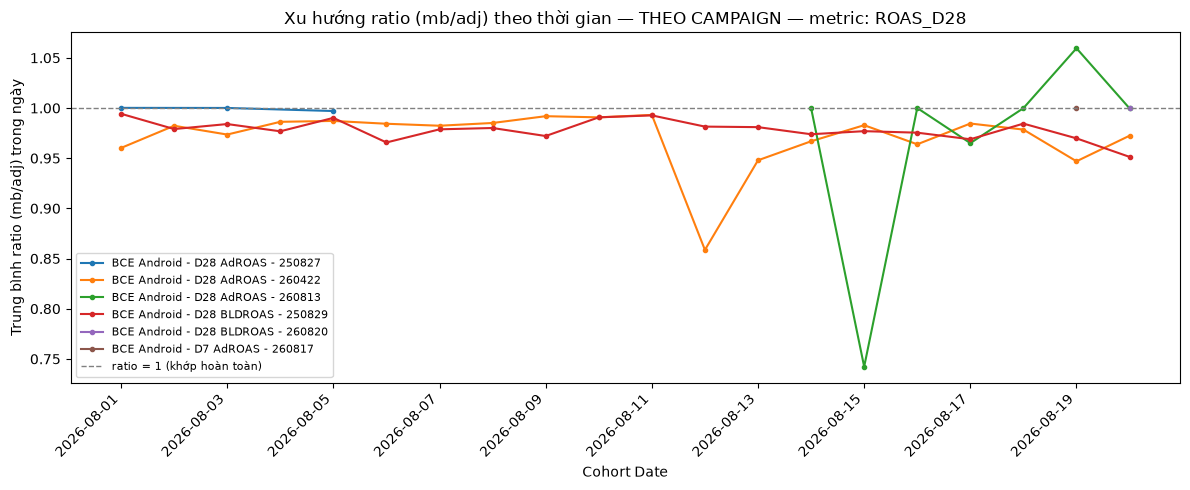

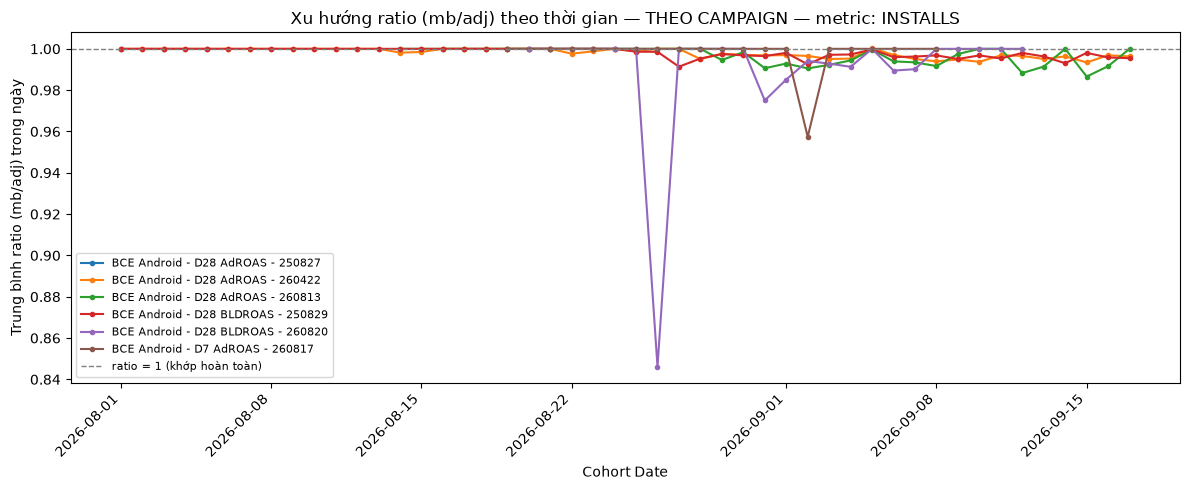

In [19]:
# Total — gộp mọi campaign
eda.plot_ratio_trend(detail, metrics=["ROAS_D0", "REVENUE_D0", "ROAS_D7", "REVENUE_D7", "INSTALLS"])

# Theo từng Campaign — đổi metric để xem chỉ số khác (VD "COST", "REVENUE_D7"...)
eda.plot_ratio_trend_by_campaign(detail, metric="ROAS_D0")
eda.plot_ratio_trend_by_campaign(detail, metric="ROAS_D28")
eda.plot_ratio_trend_by_campaign(detail, metric="INSTALLS")

### 8.7. Phân bố sai số tương đối — Histogram & ECDF
- **Histogram (tất cả Campaign)**: 1 ô/metric, thấy hình dạng phân bố thật (lệch, đa đỉnh...).
- **Histogram theo Campaign**: 1 ô/campaign, cho 1 metric cụ thể — phát hiện campaign nào
  gây lệch phân bố chung.
- **ECDF**: trả lời trực tiếp "bao nhiêu % cohort đạt ngưỡng ±5%?" — đọc tại giao điểm với
  đường ngưỡng đỏ.

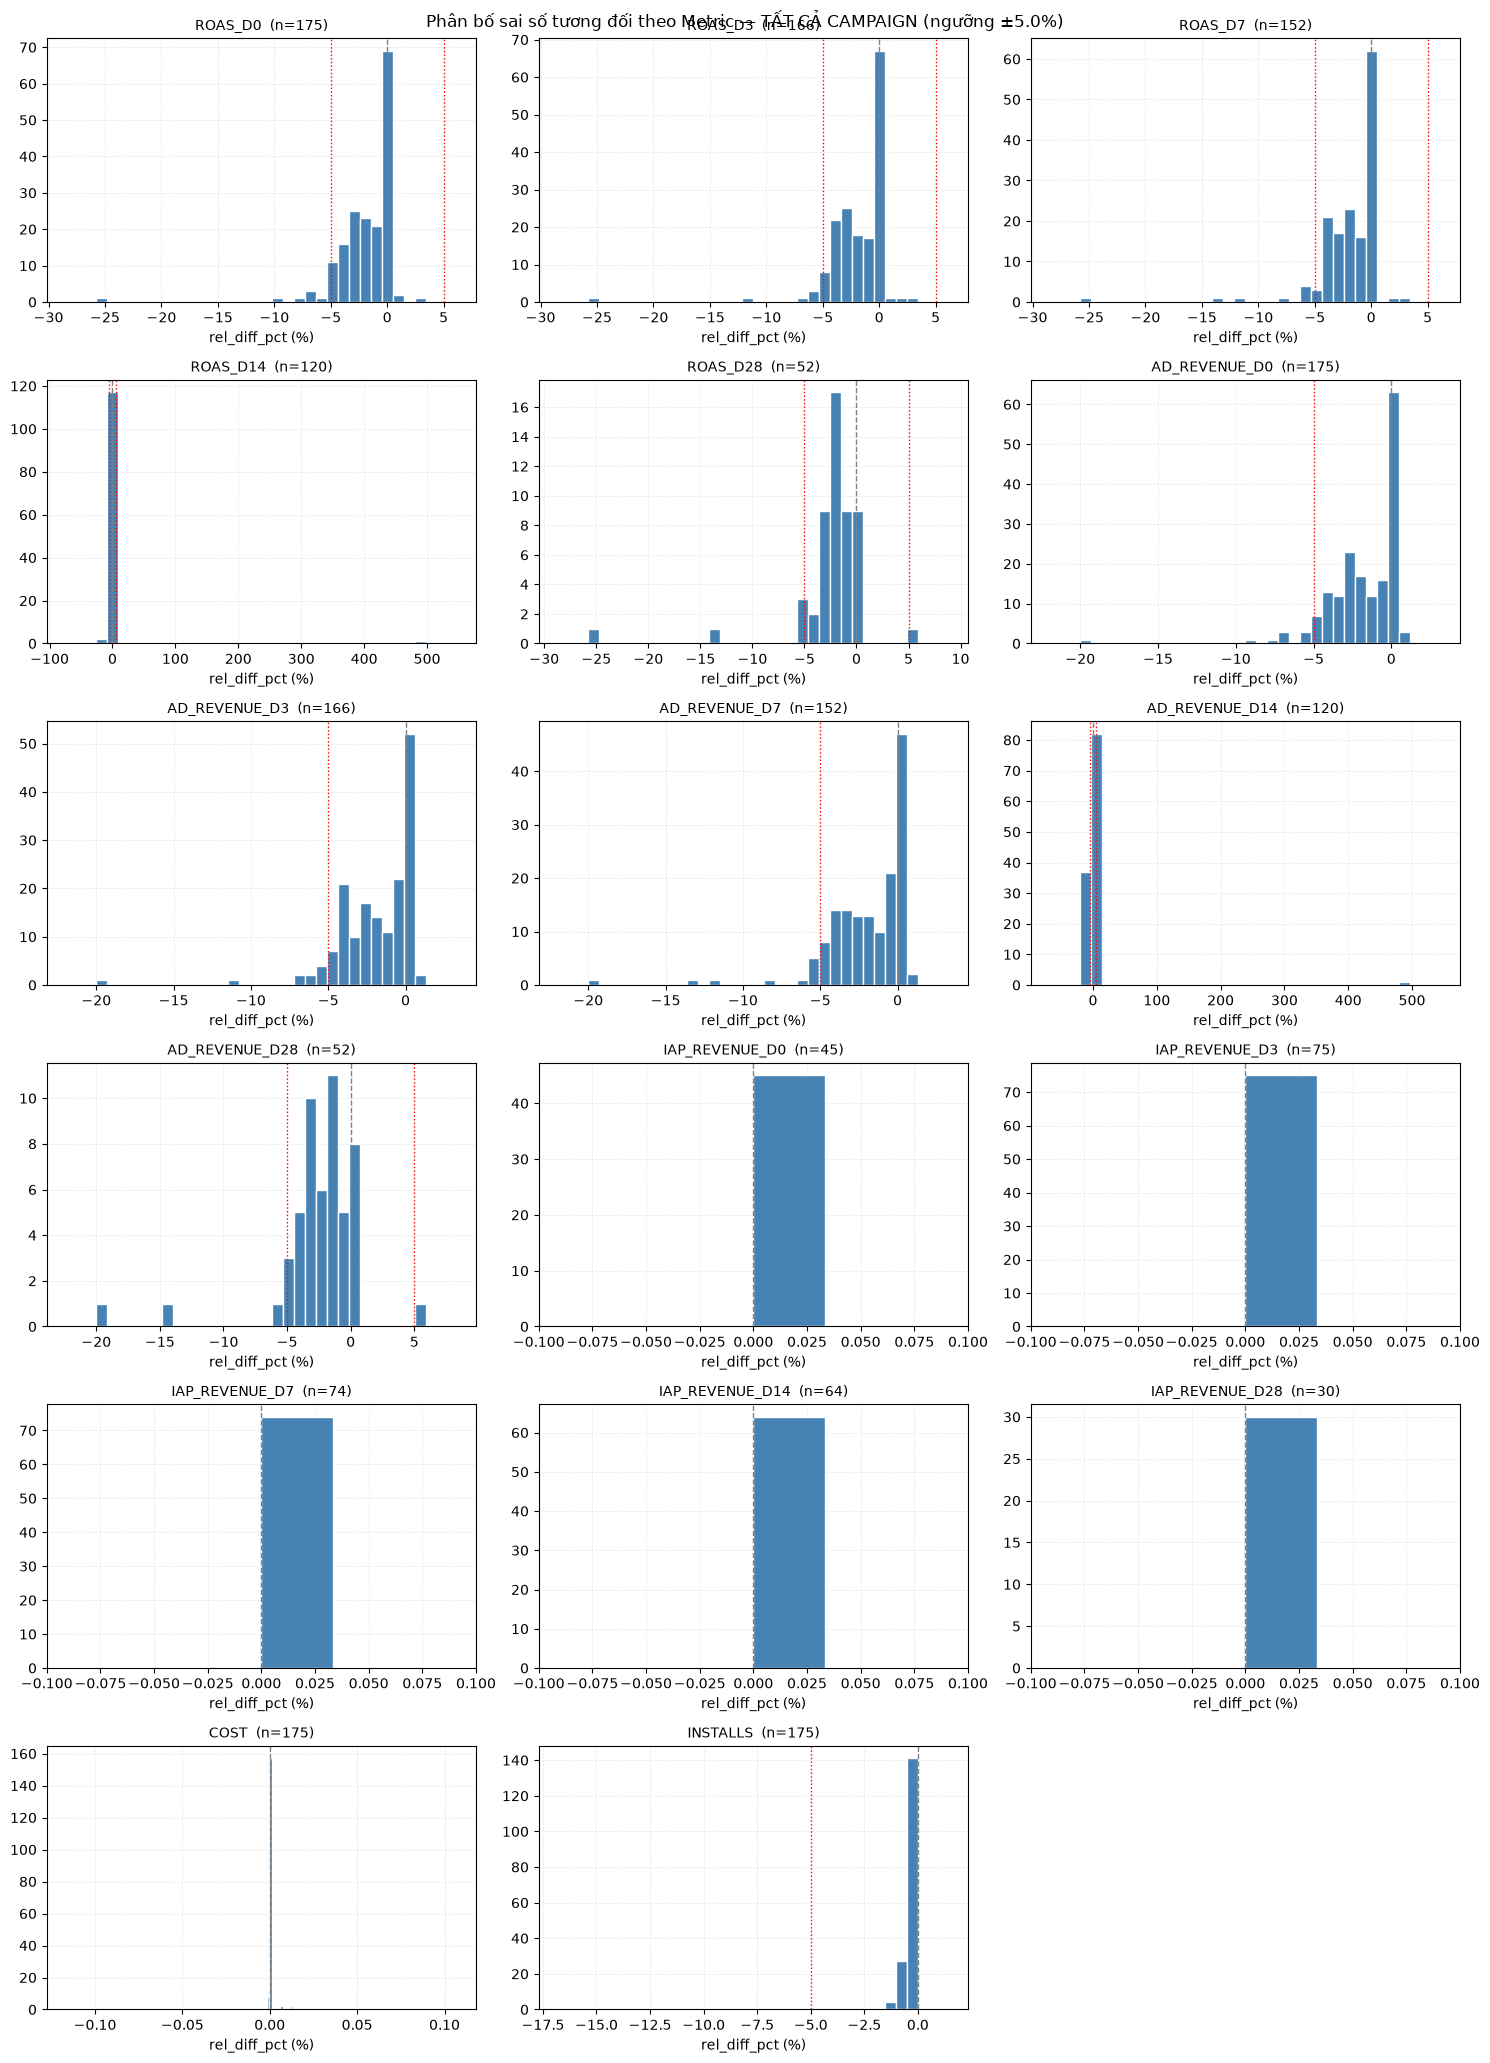

In [20]:
eda.plot_rel_diff_histogram(detail)

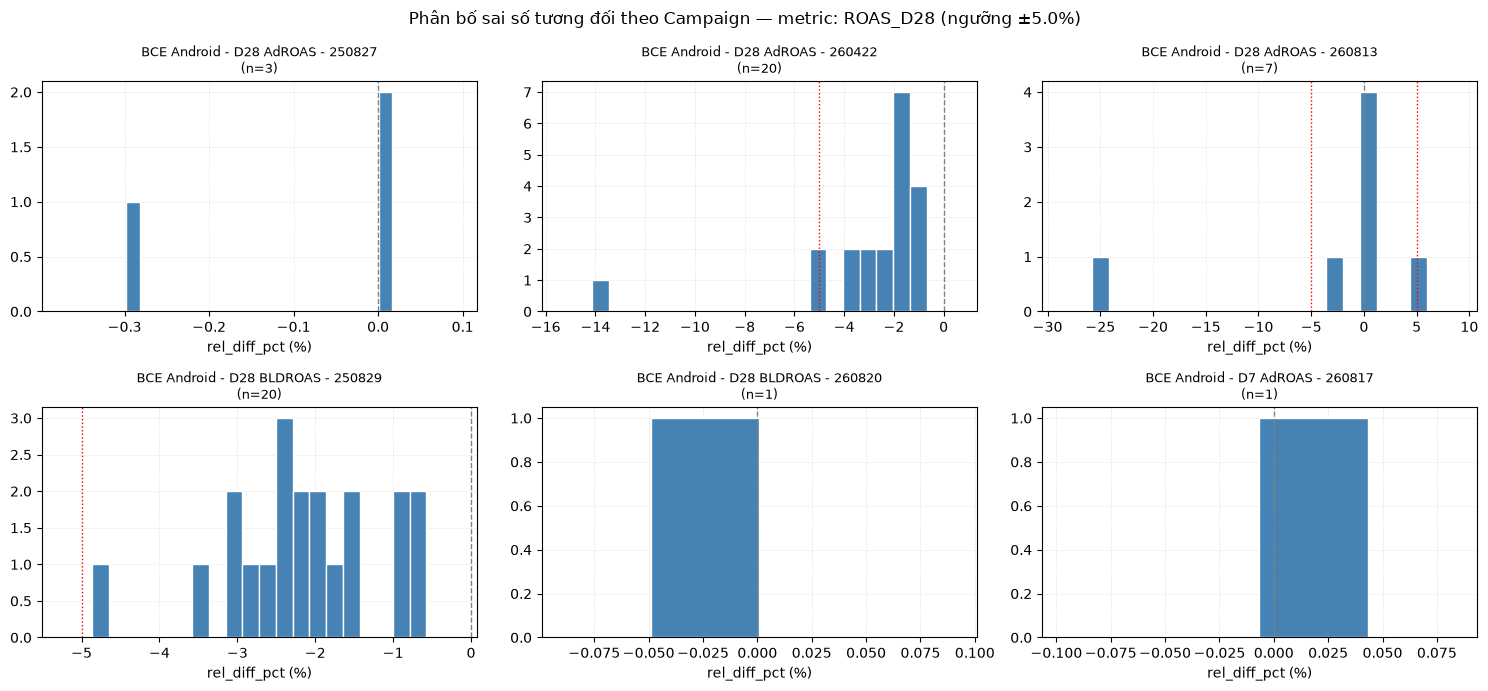

In [21]:
# Đổi metric để xem chỉ số khác (VD "COST", "REVENUE_D7"...)
eda.plot_rel_diff_histogram_by_campaign(detail, metric="ROAS_D28")

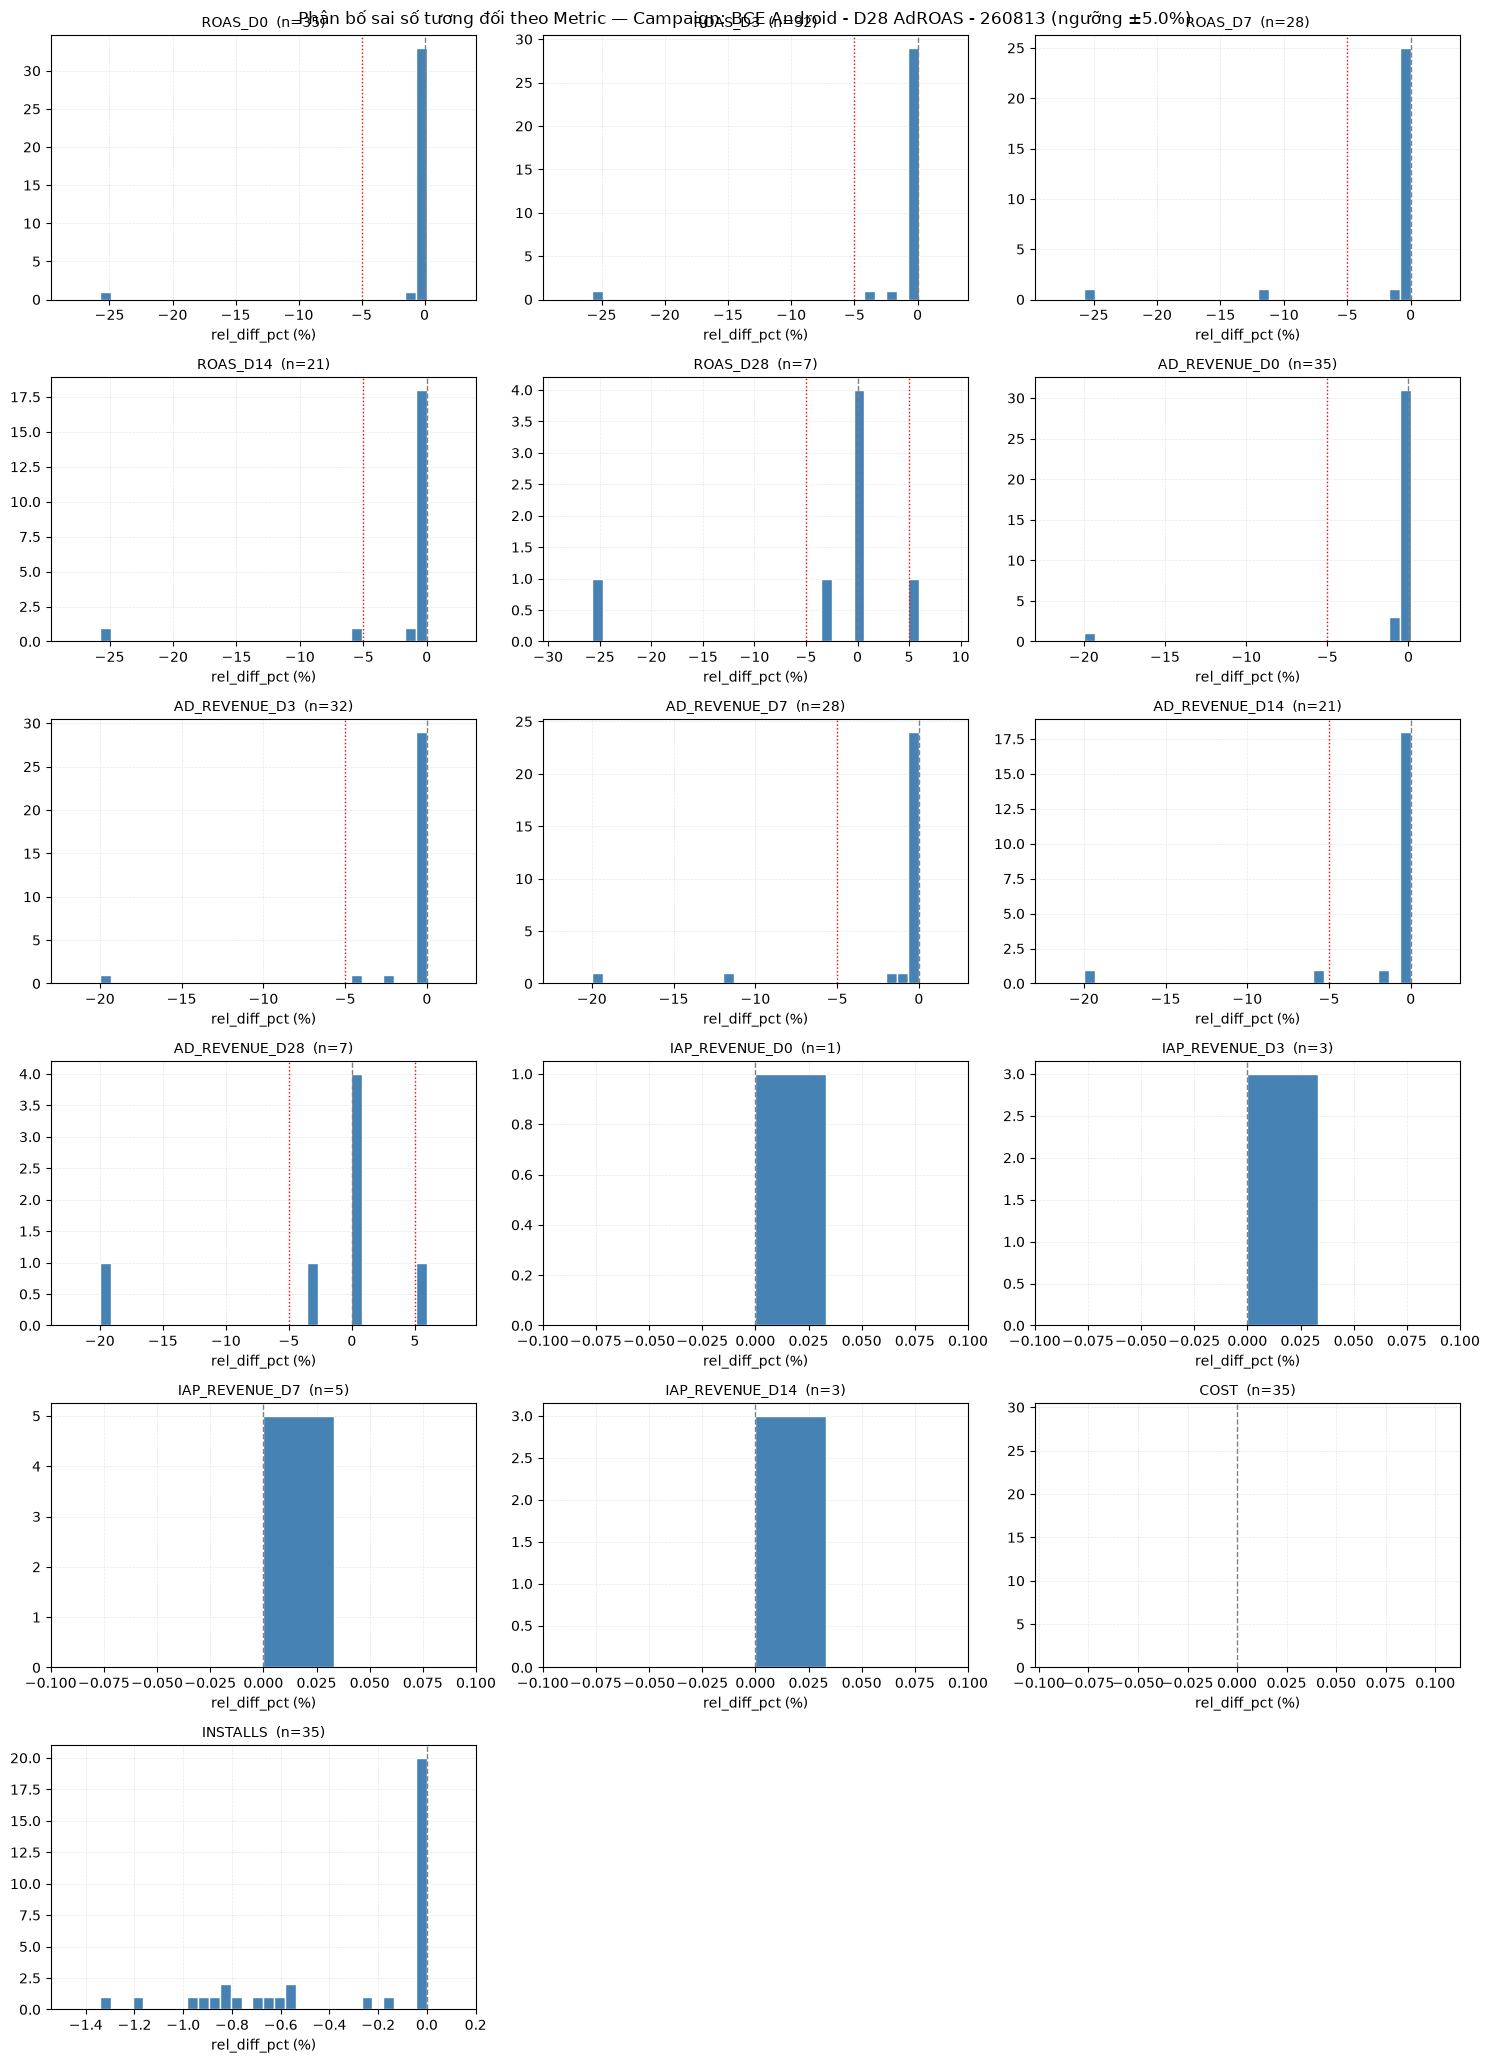

In [22]:
eda.plot_rel_diff_histogram_for_campaign(detail, campaign="BCE Android - D28 AdROAS - 260813")

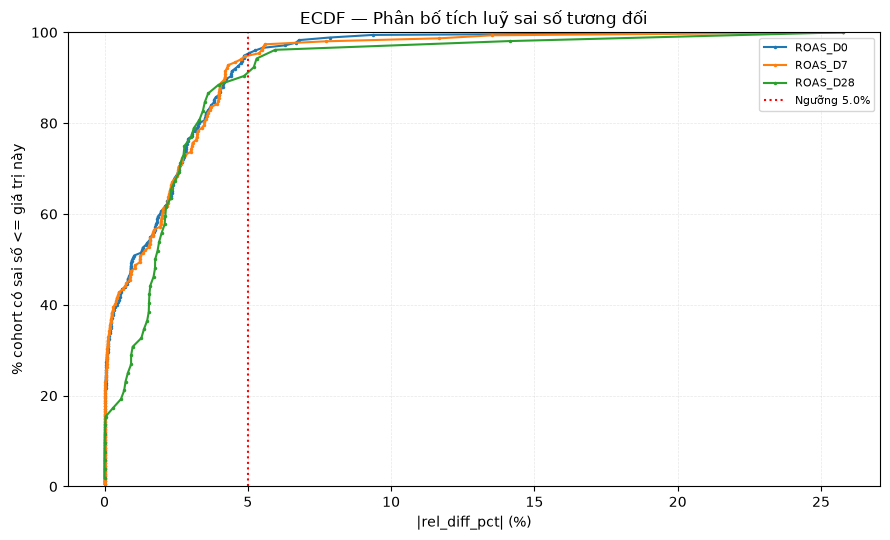

=== % cohort đạt ngưỡng (|rel_diff_pct| <= THRESHOLD_PCT) ===
  metric   n  pct_within_threshold
 ROAS_D0 175                  94.9
 ROAS_D7 152                  94.7
ROAS_D28  52                  90.4


In [23]:
pct_within_df = eda.plot_rel_diff_ecdf(detail, metrics=["ROAS_D0", "ROAS_D7", "ROAS_D28", "REVENUE_D0"])

In [24]:
from reconciliation.summary import iap_mismatches

iap_diff = iap_mismatches(detail)
print(f"{len(iap_diff)} dòng (cohort x metric) có IAP khác nhau")
iap_diff.to_csv(output_dir / "iap_mismatches.csv", index=False, encoding="utf-8-sig")
iap_diff


0 dòng (cohort x metric) có IAP khác nhau


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct,flag
